# Formation efficiency per binary -- legacy COMPAS models

This notebook computes the **formation efficiency per binary** for double
compact objects (DCOs) in *legacy* COMPAS output files, i.e. the model suite
used in [Broekgaarden et al. 2022](https://arxiv.org/abs/2103.02608) and
similar runs (a single `COMPASOutput.h5` file per model, with
`doubleCompactObjects` / `systems` / `supernovae` / ... groups).

The formation efficiency of a binary is

```
formation_efficiency = weight / total_mass_evolved_at_that_binary's_metallicity   [Msun^-1]
```

i.e. the number of such binaries formed per solar mass of star formation.

All the underlying logic lives in
[`fe_legacy_COMPAS_functions.py`](./fe_legacy_COMPAS_functions.py) (in this
same folder). Compared to the old `fe_legacy_compas_models.ipynb` +
`legacy_compas_scripts/`:


- The output is a per-binary `pandas.DataFrame` (seed, metallicity, weight,
  formation efficiency, + optional extra columns), which is easy to save,
  filter, and combine with other (non-legacy) formation-efficiency /
  cosmic-integration pipelines later on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

from fe_legacy_COMPAS_functions import calculate_formation_efficiency_per_binary

## Settings

Point `path` at a legacy `COMPASOutput.h5` file, and choose the DCO type and
the COMPAS sampling bounds (these come from the `pythonSubmit` used to run
that model, i.e. `--initial-mass-min` / `--initial-mass-max` /
`--mass-ratio-...` -> binary fraction).

In [2]:
# path to a legacy COMPAS DCO output file (e.g. one of the Broekgaarden+22 models)
path = '/Volumes/SimonsFoundation/DataDCO/fiducial/COMPASOutput.h5'

dco_type = 'BHNS'         # one of 'BBH', 'BNS', 'BHNS'

# COMPAS primary-mass sampling bounds [Msun] and assumed binary fraction
# (these are the values used for all Broekgaarden+22 models)
m1_min = 5.0
m1_max = 150.0
binary_fraction = 1.0

## Compute the formation efficiency per binary

`calculate_formation_efficiency_per_binary` does everything in one call:

1. Works out the metallicity grid simulated by COMPAS and the total stellar
   mass formed at each metallicity (`get_total_mass_evolved_per_metallicity`,
   using a Kroupa-IMF Monte-Carlo normalisation -- pass `random_seed` for
   reproducibility).
2. Selects the requested DCO type, applying the standard
   merges-within-a-Hubble-time / pessimistic-CE / no-immediate-RLOF-after-CE
   cuts (`get_dco_mask`; these can be relaxed via keyword arguments).
3. Returns one row per surviving binary with its formation efficiency.

In [3]:
binaries, metallicity_grid, total_mass_evolved_per_Z = calculate_formation_efficiency_per_binary(
    path,
    dco_type=dco_type,
    m1_min=m1_min,
    m1_max=m1_max,
    binary_fraction=binary_fraction,
    random_seed=42,  # for a reproducible IMF-sampling normalisation
)

print(f'{len(binaries)} {dco_type} binaries selected')
print(f'metallicity grid: {len(metallicity_grid)} points, '
      f'{metallicity_grid.min():.2e} - {metallicity_grid.max():.2e}')

1525553 BHNS binaries selected
metallicity grid: 53 points, 1.00e-04 - 3.00e-02


## Inspect the per-binary table

`binaries` has one row per selected DCO. `formation_efficiency` is in units
of Msun^-1 (number of such binaries formed per solar mass of star formation
at that binary's metallicity).

In [4]:
binaries.head()

,seed,metallicity,weight,formation_efficiency
0,5005630,0.0001,0.217945,2.805403e-09
1,45002757,0.0001,0.135793,1.747939e-09
2,45004818,0.0001,0.027045,3.481299e-10
3,45012446,0.0001,0.125078,1.610020e-09
4,45021855,0.0001,0.211635,2.724187e-09


In [5]:
binaries['formation_efficiency'].describe()

count    1.525553e+06
mean     1.955362e-10
std      4.014850e-10
min      2.702596e-11
25%      6.517000e-11
50%      1.096605e-10
75%      1.860396e-10
max      4.156934e-08
Name: formation_efficiency, dtype: float64

## Formation efficiency vs. metallicity

Summing the per-binary formation efficiencies in each metallicity bin gives
the total formation efficiency of this DCO type as a function of
metallicity, $\eta(Z)$.

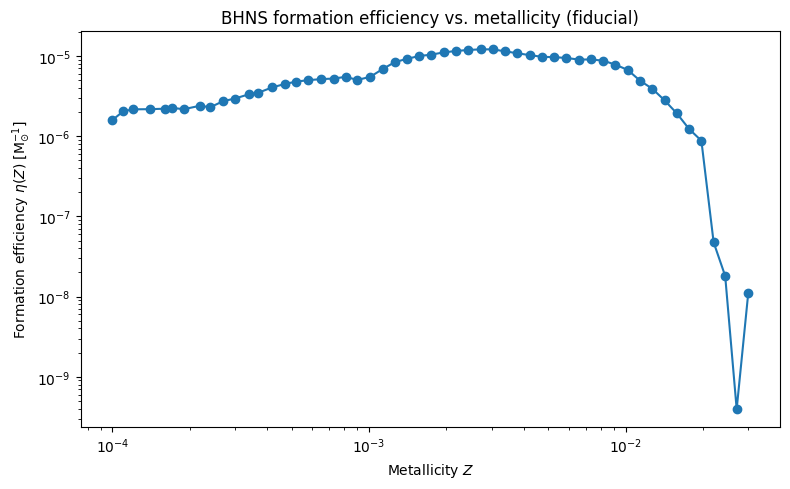

In [6]:
formation_efficiency_per_Z = (
    binaries.groupby('metallicity')['formation_efficiency']
    .sum()
    .reindex(metallicity_grid, fill_value=0.0)
)

plt.figure(figsize=(8, 5))
plt.plot(metallicity_grid, formation_efficiency_per_Z, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Metallicity $Z$')
plt.ylabel(r'Formation efficiency $\eta(Z)$ [M$_{\odot}^{-1}$]')
plt.title(f'{dco_type} formation efficiency vs. metallicity ({path.split("/")[-2]})')
plt.tight_layout()
plt.show()

## Comparing multiple DCO types

The same file can be re-used for different DCO types (BBH / BNS / BHNS) by
calling `calculate_formation_efficiency_per_binary` again. Using the same
`random_seed` keeps the IMF-sampling normalisation identical across calls,
so the curves below are directly comparable.

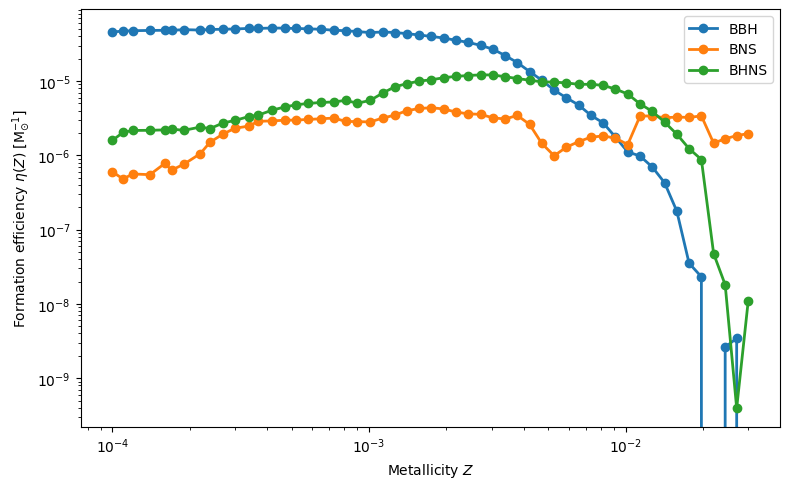

In [7]:
formation_efficiency_per_Z_by_type = {}

for t in ['BBH', 'BNS', 'BHNS']:
    df, z_grid, _ = calculate_formation_efficiency_per_binary(
        path, dco_type=t, m1_min=m1_min, m1_max=m1_max,
        binary_fraction=binary_fraction, random_seed=42,
    )
    formation_efficiency_per_Z_by_type[t] = (
        df.groupby('metallicity')['formation_efficiency'].sum().reindex(z_grid, fill_value=0.0)
    )

plt.figure(figsize=(8, 5))
for t, fe_per_Z in formation_efficiency_per_Z_by_type.items():
    plt.plot(metallicity_grid, fe_per_Z, marker='o', label=t, lw=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Metallicity $Z$')
plt.ylabel(r'Formation efficiency $\eta(Z)$ [M$_{\odot}^{-1}$]')
plt.legend()
plt.tight_layout()
plt.show()

## Notes for combining with other (non-legacy) formation-efficiency pipelines

- `extra_dco_columns` lets you pull additional columns straight from the
  `doubleCompactObjects` table alongside the formation efficiency, e.g.
  ```python
  binaries, _, _ = calculate_formation_efficiency_per_binary(
      path, dco_type='BHNS',
      extra_dco_columns=['M1', 'M2', 'tform', 'tc', 'separationDCOFormation', 'eccentricityDCOFormation'],
  )
  ```
- `binaries` is a plain `pandas.DataFrame`, so it can be saved for later use
  (e.g. `binaries.to_hdf('bhns_fiducial_fe.h5', key='binaries')` or
  `binaries.to_parquet(...)`) and combined with formation-efficiency tables
  produced by other (non-legacy) simulations downstream, as long as they
  share a common set of columns (e.g. `metallicity`, `formation_efficiency`,
  plus any of the masses / delay times above).

## Formation efficiency across all Broekgaarden+22 models

The cells below repeat the calculation above for **all 20 BPS variations
(A-T)** of [Broekgaarden et al. 2022](https://arxiv.org/abs/2103.02608), and
combine them into a 3-panel figure -- one panel per DCO type (BBH, BHNS,
BNS), each showing the formation efficiency $\eta(Z)$ of every model -- in
the style of Figure 1 of
[`make_Fig_1_and_Fig_A1.ipynb`](https://github.com/FloorBroekgaarden/Double-Compact-Object-Mergers/blob/main/plottingCode/Fig_1_and_Fig_A1/make_Fig_1_and_Fig_A1.ipynb).

`BROEKGAARDEN22_MODELS` (defined in `fe_legacy_COMPAS_functions.py`) lists
all 20 models with their data sub-directory, `optimistic` common-envelope
flag, and a plot label. Each model has its own `COMPASOutput.h5` file under
`base_path`.

**Note:** looping over all 20 (~80 GB) HDF5 files takes a while (roughly
20-30 seconds per model, i.e. ~10 minutes total). Set `models_to_run` to a
subset of `BROEKGAARDEN22_MODELS` (e.g. `BROEKGAARDEN22_MODELS[:3]`) to try
this on fewer models first.

In [8]:
from fe_legacy_COMPAS_functions import (
    calculate_formation_efficiency_vs_metallicity,
    BROEKGAARDEN22_MODELS,
)

# top-level directory containing one sub-directory per BPS model, each with
# its own COMPASOutput.h5 (m1_min, m1_max, binary_fraction are reused from
# the "Settings" section above)
base_path = '/Volumes/SimonsFoundation/DataDCO/'
file_name = 'COMPASOutput.h5'

dco_types = ['BBH', 'BHNS', 'BNS']

# all 20 models; use e.g. BROEKGAARDEN22_MODELS[:3] to try a subset first
models_to_run = BROEKGAARDEN22_MODELS

In [9]:
formation_efficiency_per_Z = {dco_type: {} for dco_type in dco_types}
metallicity_grid = None

for model in models_to_run:
    model_path = base_path + model['directory'] + '/' + file_name
    print(f"model {model['name']} ({model['directory']}, optimistic={model['optimistic']}) ...")

    metallicity_grid, eta_per_type = calculate_formation_efficiency_vs_metallicity(
        model_path,
        dco_types=dco_types,
        m1_min=m1_min,
        m1_max=m1_max,
        binary_fraction=binary_fraction,
        optimistic=model['optimistic'],
        random_seed=42,
    )
    for dco_type in dco_types:
        formation_efficiency_per_Z[dco_type][model['name']] = eta_per_type[dco_type]

print('done')

model A (fiducial, optimistic=False) ...
model B (massTransferEfficiencyFixed_0_25, optimistic=False) ...
model C (massTransferEfficiencyFixed_0_5, optimistic=False) ...
model D (massTransferEfficiencyFixed_0_75, optimistic=False) ...
model E (unstableCaseBB, optimistic=False) ...
model F (unstableCaseBB, optimistic=True) ...
model G (alpha0_1, optimistic=False) ...
model H (alpha0_5, optimistic=False) ...
model I (alpha2_0, optimistic=False) ...
model J (alpha10, optimistic=False) ...
model K (fiducial, optimistic=True) ...
model L (rapid, optimistic=False) ...
model M (maxNSmass2_0, optimistic=False) ...
model N (maxNSmass3_0, optimistic=False) ...
model O (noPISN, optimistic=False) ...
model P (ccSNkick_100km_s, optimistic=False) ...
model Q (ccSNkick_30km_s, optimistic=False) ...
model R (noBHkick, optimistic=False) ...
model S (wolf_rayet_multiplier_0_1, optimistic=False) ...
model T (wolf_rayet_multiplier_5, optimistic=False) ...
done


### Plot: $\eta(Z)$ for all 20 models, one panel per DCO type

A 3-panel figure (BBH, BHNS, BNS from top to bottom), each showing all 20
models overlaid with distinct colours/markers, log-scaled formation
efficiency on the y-axis and $\log_{10}(Z)$ on the x-axis. Dotted vertical
lines mark the solar metallicity and fractions thereof, as in Fig. 1 of
Broekgaarden et al. (2022).

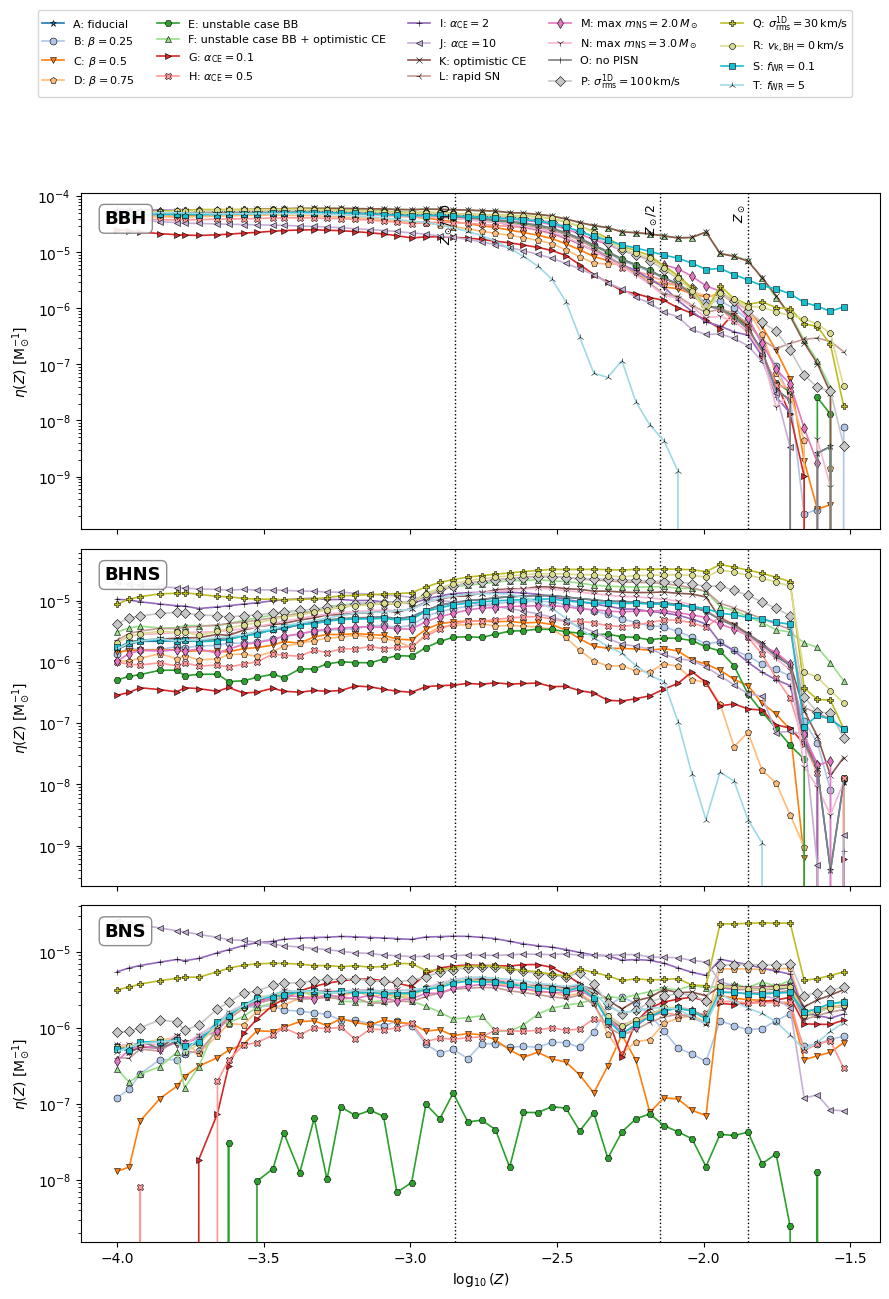

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(9, 13), sharex=True)

log10_Z = np.log10(metallicity_grid)
colors = plt.cm.tab20.colors
markers = ['*', 'o', 'v', 'p', 'H', '^', '>', 'X', '+', '<',
           'x', '3', 'd', '1', '|', 'D', 'P', '8', 's', '2']

solar = 0.0142
reference_metallicities = {
    r'$Z_\odot$': solar,
    r'$Z_\odot/2$': solar / 2,
    r'$Z_\odot/10$': solar / 10,
}

for ax, dco_type in zip(axes, dco_types):
    for i, model in enumerate(models_to_run):
        eta = formation_efficiency_per_Z[dco_type][model['name']]
        label = f"{model['name']}: {model['label']}" if dco_type == dco_types[0] else None
        ax.plot(log10_Z, eta, color=colors[i % len(colors)], marker=markers[i % len(markers)],
                markersize=5, markeredgecolor='k', mew=0.4, lw=1.2, label=label)

    for Z_label, Z in reference_metallicities.items():
        ax.axvline(np.log10(Z), color='k', lw=1, ls=':', zorder=0)
        if dco_type == dco_types[0]:
            ax.text(np.log10(Z), 0.97, Z_label, transform=ax.get_xaxis_transform(),
                    rotation=90, va='top', ha='right', fontsize=9)

    ax.set_yscale('log')
    ax.set_ylabel(r'$\eta(Z)$ [M$_{\odot}^{-1}$]')
    ax.annotate(dco_type, xy=(0.03, 0.95), xycoords='axes fraction', fontsize=13, weight='bold',
                ha='left', va='top', bbox=dict(boxstyle='round', fc='w', ec='0.5', alpha=0.9))

axes[-1].set_xlabel(r'$\log_{10}(Z)$')
fig.tight_layout(rect=[0, 0, 1, 0.87])
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=5, fontsize=8)
plt.show()



This looks exactly like the plots in https://ui.adsabs.harvard.edu/abs/2022MNRAS.516.5737B/abstract :-) so we are happy 